In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/trait_counts_cleaned.csv')

X = df.drop(columns=['top_four'])
y = df['top_four']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,   
    random_state=42, stratify = y  
)
feature_columns = df.drop(columns = ['top_four']).columns.tolist()

regression_training_data = pd.DataFrame(X_train, columns = feature_columns)
regression_training_data.to_csv("../data/regression_training_data.csv", index=False)

regression_testing_data = pd.DataFrame(X_test, columns = feature_columns)
regression_testing_data.to_csv("../data/regression_testing_data.csv", index=False)

Logistic-regression accuracy: 70.66%


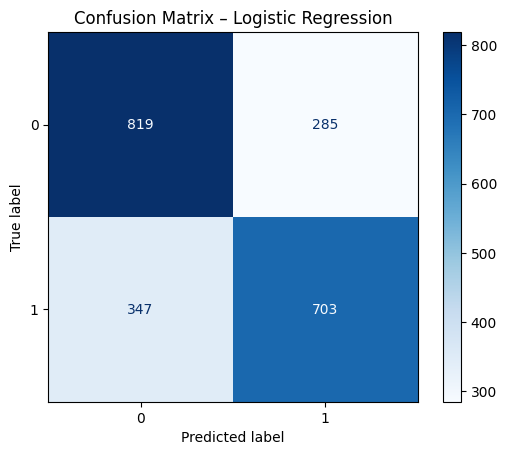

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

logreg_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),          
        ("logreg",  LogisticRegression(
            max_iter=500,                      
            class_weight="balanced",           
            solver="lbfgs"))
    ]
)

logreg_pipe.fit(X_train, y_train)

y_pred = logreg_pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Logistic-regression accuracy: {acc:.2%}")

cm = confusion_matrix(y_test, y_pred, labels=logreg_pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=logreg_pipe.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()